# Aula 26/06/2026 - VIS101

## Bibliotecas 

In [140]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.segmentation import felzenszwalb # pip install scikit-image
import math


In [56]:
img = cv2.imread('imgs/input.png')

print(img.shape) # (948, 1264, 3) largura, altura, canais
print(type(img))

(639, 816, 3)
<class 'numpy.ndarray'>


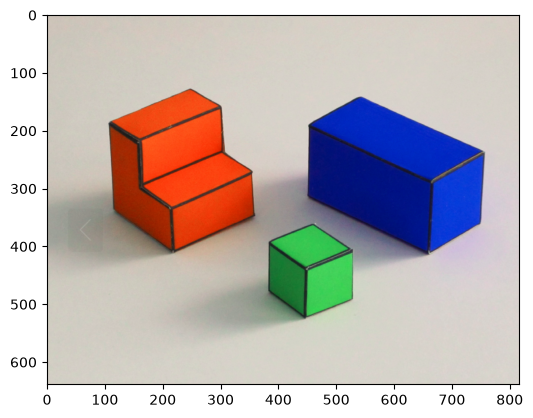

In [57]:
plt.imshow(img)
plt.show()

In [58]:
cv2.imshow("Imagem", img)
cv2.waitKey(0)      # espera até uma tecla ser pressionada
cv2.destroyAllWindows()

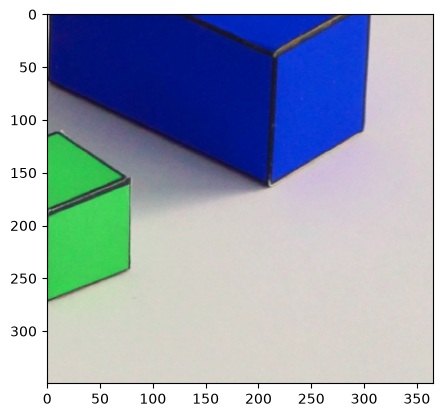

In [59]:
roi = img[250:600, 450:900]
plt.imshow(roi)
plt.show()

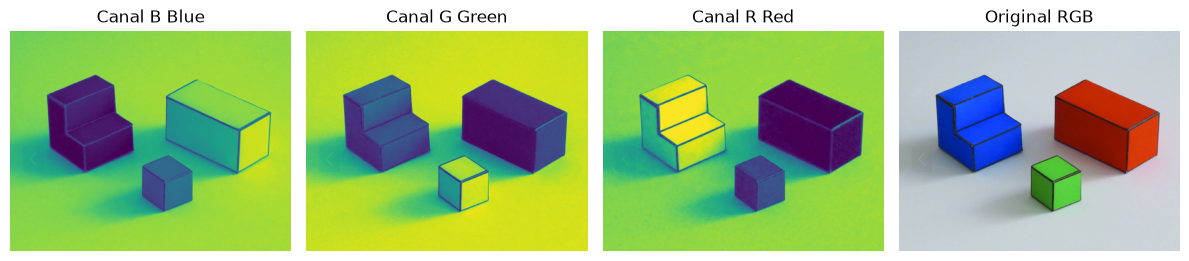

In [98]:
B, G, R = cv2.split(img)

fig, axes = plt.subplots(1, 4, figsize=(12, 4))


axes[0].imshow(B)
axes[0].set_title('Canal B Blue')
axes[0].axis('off')

axes[1].imshow(G)
axes[1].set_title('Canal G Green')
axes[1].axis('off')

axes[2].imshow(R)
axes[2].set_title('Canal R Red')
axes[2].axis('off')

axes[3].imshow(img)
axes[3].set_title('Original RGB')
axes[3].axis('off')


plt.tight_layout()
plt.show()

(948, 1264, 3)
<class 'numpy.ndarray'>


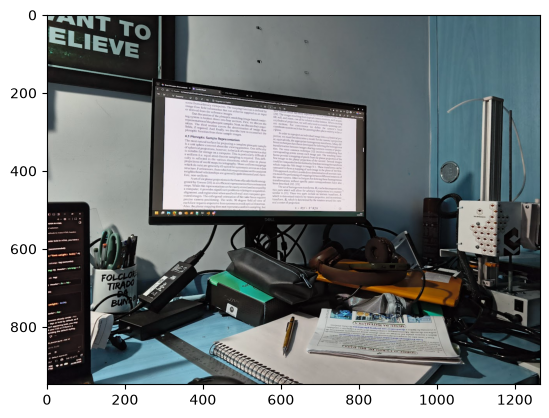

In [100]:
img = cv2.imread('imgs/panorama1.png')

print(img.shape) # (948, 1264, 3) largura, altura, canais
print(type(img))

plt.imshow(img)
plt.show()

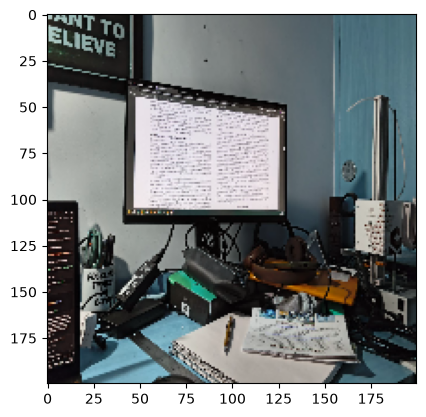

In [105]:
pequena = cv2.resize(img, (200, 200))

plt.imshow(pequena)

plt.show()

(474, 632, 3)


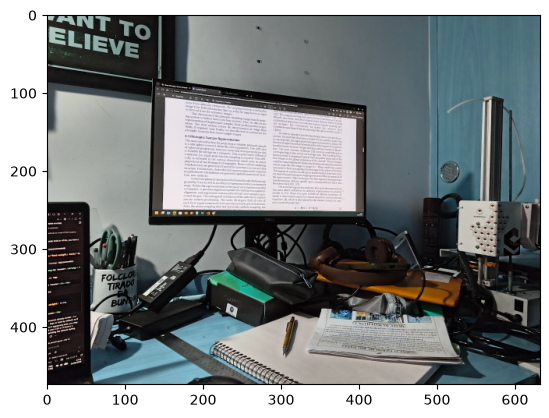

In [103]:
metade = cv2.resize(img, None, fx=0.5, fy=0.5)
print(metade.shape)

plt.imshow(metade)
plt.show()

#### Escalando a imagem

In [ ]:
h, w = img.shape[:2]
factorS = 2

new_width=w*factorS
new_height=h*factorS
# Resize the image
resized_image = cv2.resize(img, (new_width, new_height))
 
# Display the resized image
# cv2.imshow("Resized Image", resized_image)
# cv2.waitKey(0)
# cv2.destroyAllWindows()


plt.imshow(resized_image)
plt.show()


[[0.5 0.  0. ]
 [0.  0.5 0. ]]


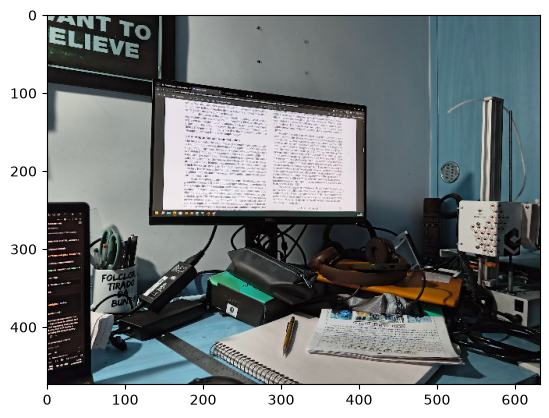

In [139]:
fx = 0.5
fy = 0.5

M_scaling = np.float32([[fx, 0, 0], [0, fy, 0]])

print(M_scaling)

# Calculate new dimensions for warpAffine
scaled_w = int(w * fx)
scaled_h = int(h * fy)

# Apply the scalling transformation
escalada = cv2.warpAffine(img, M_scaling, (scaled_w, scaled_h))



plt.imshow(escalada)
plt.show()


### Rotacionando a imagem 

[[   0.8660254     0.5        -152.32805519]
 [  -0.5           0.8660254   379.50395861]]


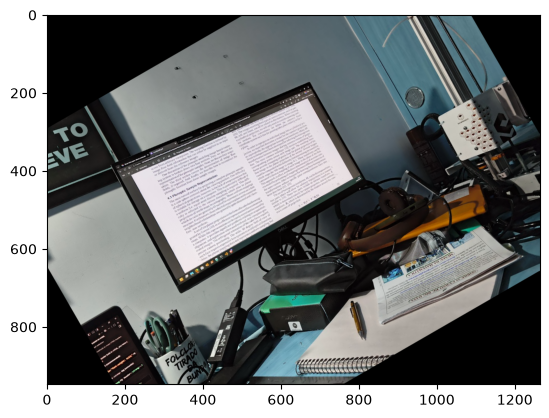

In [189]:
angle = 30
scale = 1.0

# image center of rotation
center = (w//2, h//2)

M_rotation = cv2.getRotationMatrix2D(center, angle, scale)
rotacionada = cv2.warpAffine(img, M_rotation, (w, h))

print(M_rotation)

plt.imshow(rotacionada)
plt.show()


In [190]:
M_rotation

array([[   0.8660254 ,    0.5       , -152.32805519],
       [  -0.5       ,    0.8660254 ,  379.50395861]])

In [192]:
M_rotation_angles = M_rotation[:, :2] # get the first two columns
M_rotation_angles

array([[ 0.8660254,  0.5      ],
       [-0.5      ,  0.8660254]])

cos(angulo), sen(angulo) </br>
-sen(angulo), cos(angulo)

In [233]:
print(f'cos({angle}) = {M_rotation[0][0]:.7f} arccos {np.round(np.degrees(np.arccos(M_rotation[0][0])))} degrees')
print(f'sin({angle}) = {M_rotation[0][1]:.7f} arcsin {np.round(np.degrees(np.arcsin(M_rotation[0][1])))} degrees')

print(f'-sin({angle}) = {M_rotation[1][0]:.7f} arcsin {np.round(np.degrees(np.arcsin(-M_rotation[1][0])))} degrees')
print(f'cos({angle}) = {M_rotation[1][1]:.7f} arccos {np.round(np.degrees(np.arccos(M_rotation[1][1])))} degrees')


cos(30) = 0.8660254 arccos 30.0 degrees
sin(30) = 0.5000000 arcsin 30.0 degrees
-sin(30) = -0.5000000 arcsin 30.0 degrees
cos(30) = 0.8660254 arccos 30.0 degrees


In [235]:
for row in M_rotation_angles:
    for value in row:
        print(value)

0.8660254037844387
0.49999999999999994
-0.49999999999999994
0.8660254037844387


In [234]:

angle_rad = np.radians(angle)

print(math.sin(-angle_rad))

print(math.cos(angle_rad))





-0.49999999999999994
0.8660254037844387


## Chapter 2 - A Simple Vision System

Using Chatgpt 

https://visionbook.mit.edu/simplesystem.html

#### 1. Load Image

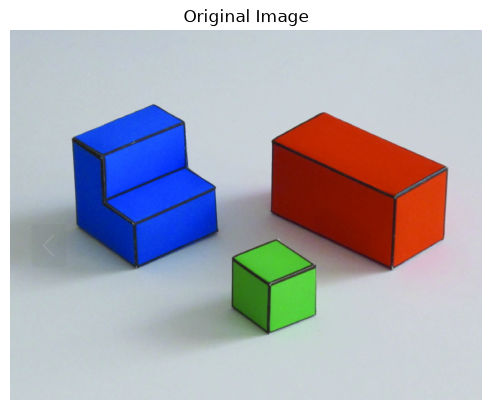

In [61]:
img = cv2.imread("imgs/input.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

#### 2. Convert to Grayscale

The vision system starts with intensity values.

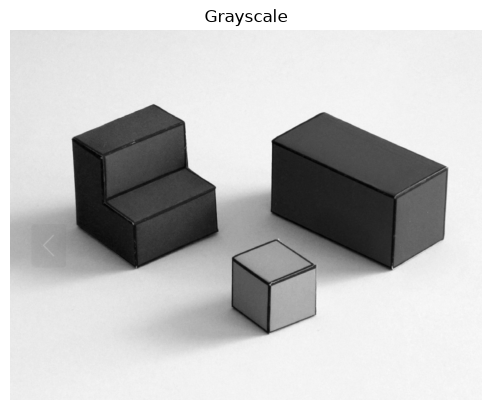

In [62]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")
plt.show()

#### 3. Compute Image Gradient (Sobel)

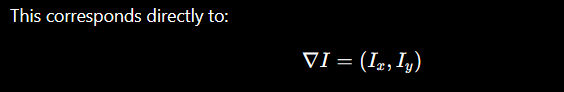

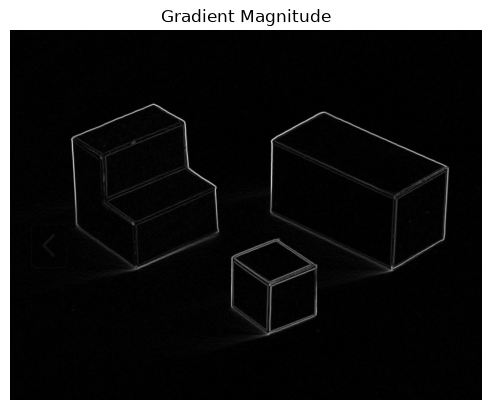

In [63]:
Ix = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
Iy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

magnitude = np.sqrt(Ix**2 + Iy**2)
orientation = np.arctan2(Iy, Ix)

plt.imshow(magnitude, cmap='gray')
plt.title("Gradient Magnitude")
plt.axis("off")
plt.show()

#### 4. Edge Detection

Equivalent to the edge extraction stage.


https://www.geeksforgeeks.org/python/python-opencv-canny-function/

https://www.geeksforgeeks.org/python/real-time-edge-detection-using-opencv-python/

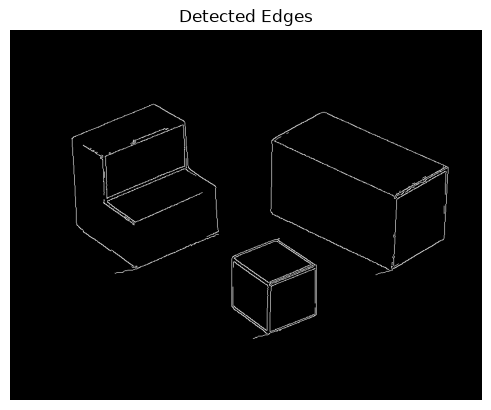

In [96]:
t_lower = 50  
t_upper = 150 
edges = cv2.Canny(gray, t_lower, t_upper)

plt.imshow(edges, cmap='gray')
plt.title("Detected Edges")
plt.axis("off")
plt.show()

#### 5. Visualize Edge Orientation

Classify edge direction.

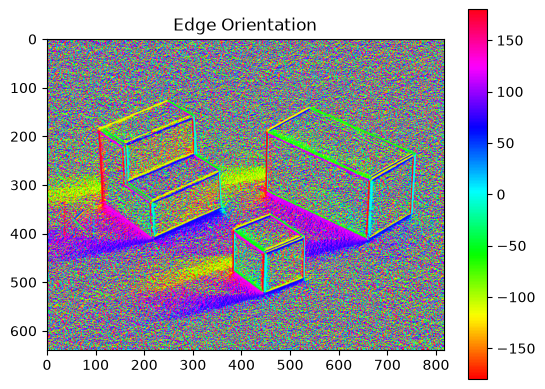

In [65]:
orientation_deg = np.rad2deg(orientation)

plt.imshow(orientation_deg, cmap='hsv')
plt.title("Edge Orientation")
plt.colorbar()
plt.show()

Interpretation:

0°    → vertical

90°   → horizontal

45°   → diagonal

#### 6. Detect Long Straight Edges

Approximate object boundaries.

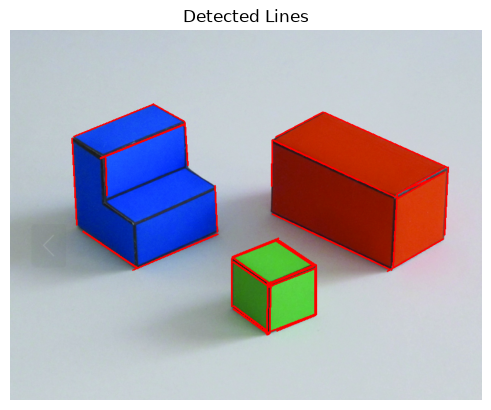

In [66]:
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi/180,
    threshold=50,
    minLineLength=50,
    maxLineGap=10
)

line_img = img.copy()

if lines is not None:
    for l in lines:
        x1,y1,x2,y2 = l[0]
        cv2.line(
            line_img,
            (x1,y1),
            (x2,y2),
            (255,0,0),
            2
        )

plt.imshow(line_img)
plt.title("Detected Lines")
plt.axis("off")
plt.show()

#### 7. Segment Regions

The MIT example separates surfaces.

A simple version:

use 

```
pip install scikit-image
```

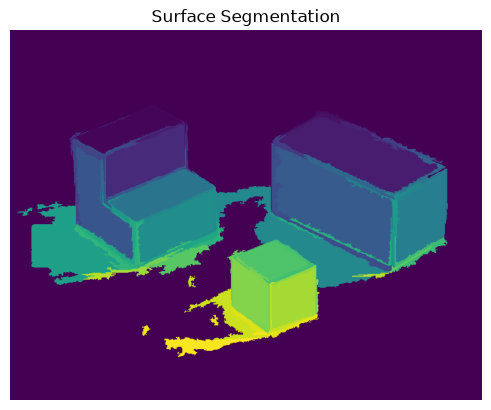

In [67]:
segments = felzenszwalb(
    img,
    scale=100,
    sigma=0.5,
    min_size=100
)

plt.imshow(segments)
plt.title("Surface Segmentation")
plt.axis("off")
plt.show()

#### 8. Estimate Surface Normals (Simplified)

Use image gradients as a crude approximation.

In [68]:
dx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
dy = cv2.Sobel(gray, cv2.CV_64F, 0, 1)

normal_x = -dx
normal_y = -dy
normal_z = np.ones_like(dx)

norm = np.sqrt(
    normal_x**2 +
    normal_y**2 +
    normal_z**2
)

normal_x /= norm
normal_y /= norm
normal_z /= norm

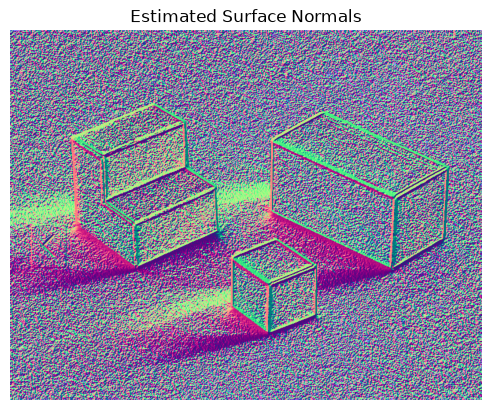

In [69]:
normal_rgb = np.dstack([
    (normal_x + 1)/2,
    (normal_y + 1)/2,
    (normal_z + 1)/2
])

plt.imshow(normal_rgb)
plt.title("Estimated Surface Normals")
plt.axis("off")
plt.show()

#### 9. Recover Relative Depth

A simplified "shape from shading" approach.

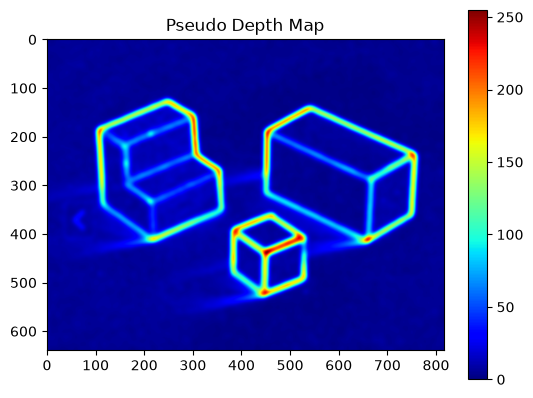

In [70]:
depth = cv2.GaussianBlur(
    magnitude,
    (31,31),
    0
)

depth = cv2.normalize(
    depth,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

plt.imshow(depth, cmap='jet')
plt.title("Pseudo Depth Map")
plt.colorbar()
plt.show()

#### 10. Create a 3D Surface

cmaps options

* Sequential: viridis, plasma, inferno, magma, cividis, gray
* Diverging: coolwarm, seismic, twilight
* Qualitative: tab10, Set3
* Rainbow-like: jet, turbo, rainbow

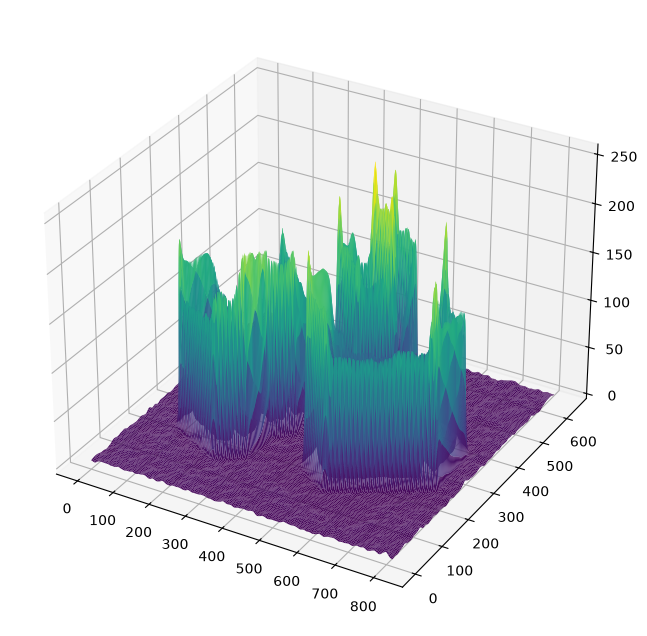

In [84]:
# from mpl_toolkits.mplot3d import Axes3D

h,w = depth.shape

X,Y = np.meshgrid(
    np.arange(w),
    np.arange(h)
)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    X,
    Y,
    depth,
    rstride=4,
    cstride=4,
    cmap='viridis'
)

plt.show()

#### Complete Pipeline Visualization

You can create a single dashboard:

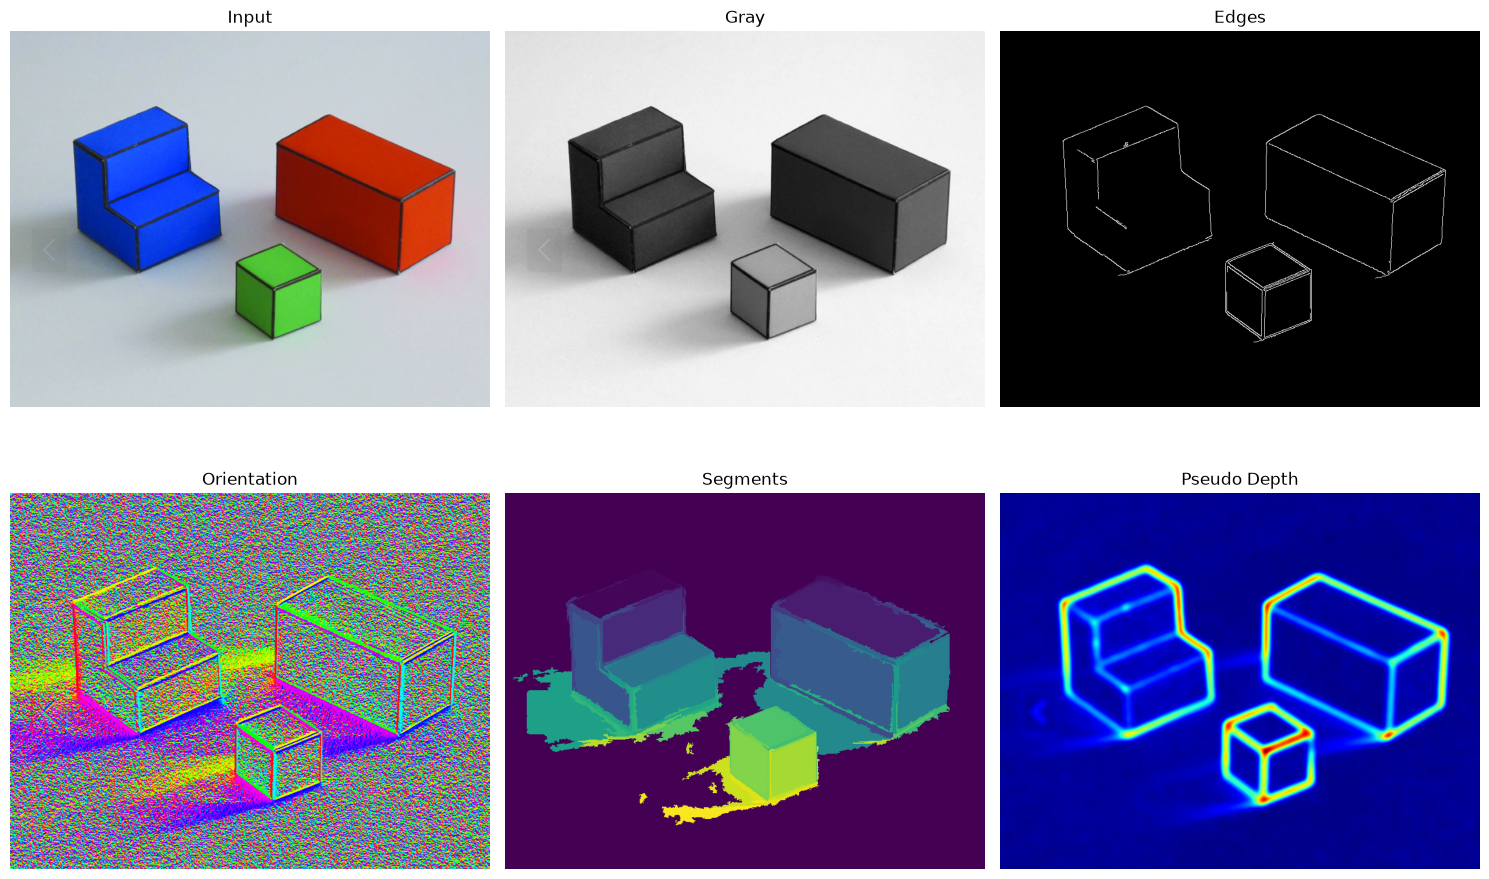

In [72]:
fig, ax = plt.subplots(2,3, figsize=(15,10))

ax[0,0].imshow(img)
ax[0,0].set_title("Input")

ax[0,1].imshow(gray, cmap='gray')
ax[0,1].set_title("Gray")

ax[0,2].imshow(edges, cmap='gray')
ax[0,2].set_title("Edges")

ax[1,0].imshow(orientation_deg, cmap='hsv')
ax[1,0].set_title("Orientation")

ax[1,1].imshow(segments)
ax[1,1].set_title("Segments")

ax[1,2].imshow(depth, cmap='jet')
ax[1,2].set_title("Pseudo Depth")

for a in ax.ravel():
    a.axis("off")

plt.tight_layout()
plt.show()

## Matrix Transformations and Coordinate Systems with Python

https://sigmoidal.ai/en/matrix-transformations-and-coordinate-systems-with-python/

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import expm

class Camera:
    def __init__(self, P):
        self.P = P
        self.K = None
        self.R = None
        self.t = None
        self.c = None

    def translate(self, translation_vector):
        T = np.eye(4)
        T[:3, 3] = translation_vector
        self.P = np.dot(self.P, T)

    def rotate(self, rotation_vector):
        R = rotation_matrix(rotation_vector)
        self.P = np.dot(self.P, R)

    def position(self):
        return self.P[:3, 3]

def rotation_matrix(a):
    R = np.eye(4)
    R[:3, :3] = expm(np.array([[0, -a[2], a[1]], [a[2], 0, -a[0]], [-a[1], a[0], 0]]))
    return R

In [86]:
def draw_axis(ax, position, label, color):
    x_arrow = np.array([1, 0, 0])
    y_arrow = np.array([0, 1, 0])
    z_arrow = np.array([0, 0, 1])
    ax.quiver(*position, *x_arrow, color=color, arrow_length_ratio=0.1)
    ax.quiver(*position, *y_arrow, color=color, arrow_length_ratio=0.1)
    ax.quiver(*position, *z_arrow, color=color, arrow_length_ratio=0.1)
    ax.text(*(position + x_arrow), f"{label}_x")
    ax.text(*(position + y_arrow), f"{label}_y")
    ax.text(*(position + z_arrow), f"{label}_z")

def plot_world_and_camera(world_coordinates, camera):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    world_x, world_y, world_z = zip(world_coordinates)
    ax.scatter(world_x, world_y, world_z, c='b', marker='o', label='World Coordinates', s=54)

    camera_x, camera_y, camera_z = camera.position()
    ax.scatter(camera_x, camera_y, camera_z, c='r', marker='^', label='Camera Position', s=54)

    draw_axis(ax, camera.position(), "C", color="red")
    draw_axis(ax, world_origin, "W", color="blue")

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_zlim(-3, 3)
    ax.legend()
    plt.show()

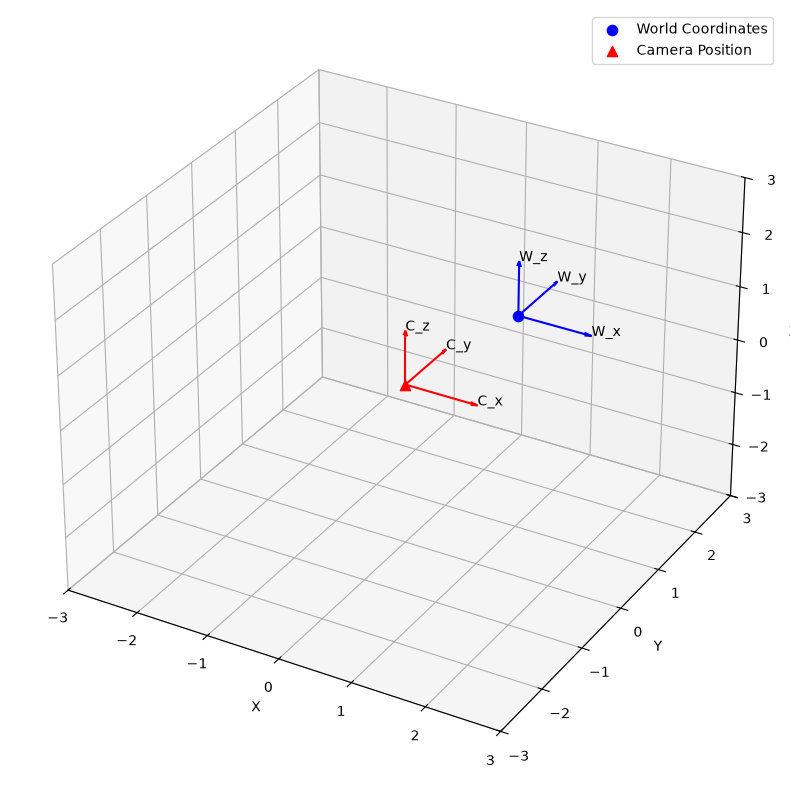

In [87]:
world_origin = (1, 1, 1)

# Set up Camera
P = np.hstack((np.eye(3), np.array([[0], [0], [0]])))
cam = Camera(P)

# Plot the World and Camera Coordinate Systems
plot_world_and_camera(world_origin, cam)

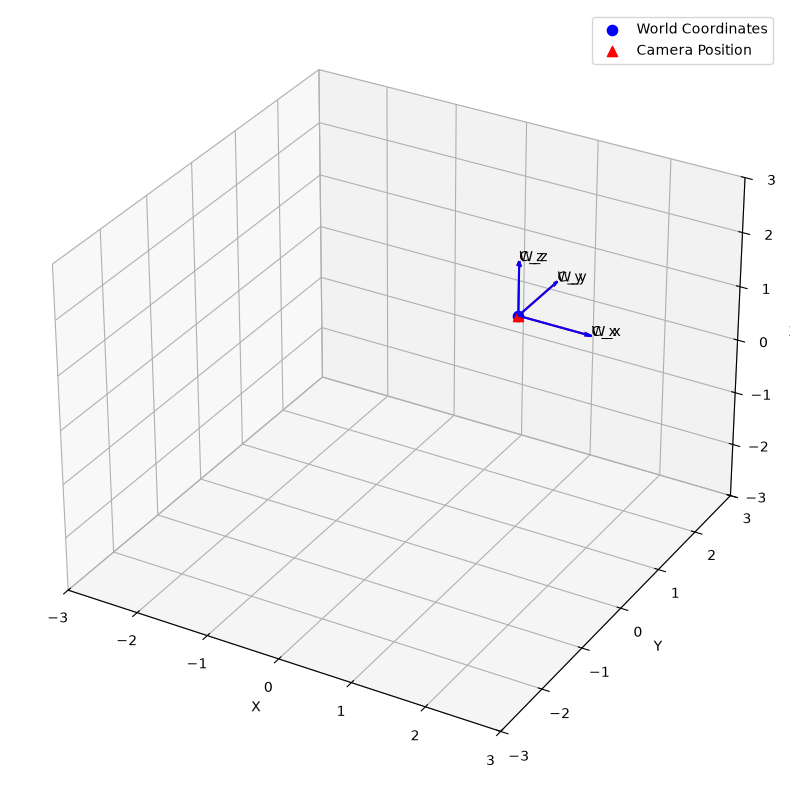

In [88]:
# Move the Camera
translation_vector = np.array([1, 1, 1])
rotation_axis = np.array([0, 0, 1])
rotation_angle = np.radians(45)
rotation_vector = rotation_axis * rotation_angle
cam.translate(translation_vector)
cam.rotate(rotation_vector)

## Plot the World and Camera Coordinate Systems after moving the Camera
plot_world_and_camera(world_origin, cam)